# Task 2: Domain Adaptation

## 1. Setup




In [ ]:
import json, math, random, shutil, zipfile, os
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = False
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from tqdm.auto import tqdm
from IPython.display import display
SEED=6304; DOMAINS=('photo','art_painting','cartoon'); TARGET='sketch'
CLASSES=('dog','elephant','giraffe','guitar','horse','house','person')
RUNS=(('Source-only',0.),('DAN 0.1',0.1),('DAN 1',1.),('DAN 10',10.),('DANN',1.),('CDAN',1.))
OUT=Path('/content/drive/MyDrive/ATML_PA1/Task2_PACS_stabilized/results'); OUT.mkdir(parents=True,exist_ok=True)
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
assert DEVICE=='cuda','Select a Colab GPU runtime.'
def seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
seed_all(SEED)
torch.backends.cudnn.benchmark=False
torch.backends.cudnn.deterministic=True
print('Device:',torch.cuda.get_device_name(0),'| PyTorch:',torch.__version__)
config={'seed':SEED,'sources':DOMAINS,'target':TARGET,'classes':CLASSES,'model':'torchvision resnet18 ResNet18_Weights.IMAGENET1K_V1',
 'batch_per_source':8,'batch_target':24,'optimizer':'AdamW','lr':1e-4,'weight_decay':1e-4,
 'epochs_max':30,'early_stop_patience':5,'selection':'mean of three source-validation macro-F1',
 'bn':'ImageNet running statistics frozen, affine parameters trainable',
 'dan_lambdas':[0.1,1,10],'dann_cdan_grl':'2/(1+exp(-10p))-1, p=global update/max-30-epoch updates',
 'domain_loss_weight':1,'global_grad_clip_norm':1.0,
 'discriminator_feature_input':'L2-normalized feature times sqrt(512), for DANN and CDAN only',
 'discriminator_last_layer_init':'zeros','domain_discriminator':'256 ReLU dropout 0.5 2',
 'diagnostic':'equal source validation and target counts, 70/30 stratified, balanced logistic regression C=1'}
(OUT/'config.json').write_text(json.dumps(config,indent=2))

Mounted at /content/drive
Device: NVIDIA A100-SXM4-40GB | PyTorch: 2.11.0+cu128


1074

## 2. PACS download and fixed source splits



In [ ]:
PACS_INPUT=Path('/content/PACS')
HF_REPO='Azeez577/PACS'
HF_REVISION='46a0a83'  # PACS.zip upload commit
HF_SHA256='42bf567f1ed8a01d522e47e4a677e2a3149577bbd6fcbb38bedfdd73cb59e147'
if not PACS_INPUT.exists():
    import hashlib, subprocess, sys
    archive=Path('/content/PACS.zip')
    if archive.exists() and not zipfile.is_zipfile(archive): archive.unlink()
    if not archive.exists():
        subprocess.run([sys.executable,'-m','pip','install','-q','huggingface_hub'],check=True)
        from huggingface_hub import hf_hub_download
        archive=Path(hf_hub_download(repo_id=HF_REPO,repo_type='dataset',
                                     filename='PACS.zip',revision=HF_REVISION,
                                     local_dir='/content'))
    assert zipfile.is_zipfile(archive),'The downloaded PACS file is not a valid ZIP.'
    digest=hashlib.sha256()
    with archive.open('rb') as stream:
        for chunk in iter(lambda:stream.read(8*1024*1024),b''):digest.update(chunk)
    assert digest.hexdigest()==HF_SHA256, (
        'PACS archive hash mismatch. Delete /content/PACS.zip and retry the download.')
    PACS_INPUT=archive
if PACS_INPUT.is_file():
    assert PACS_INPUT.suffix.lower()=='.zip','Expected a folder or .zip.'
    extract=Path('/content/PACS_extracted'); extract.mkdir(exist_ok=True)
    with zipfile.ZipFile(PACS_INPUT) as z:
        assert z.testzip() is None,'PACS archive has a damaged member; delete /content/PACS.zip and retry.'
        for info in z.infolist():
            path=(extract/info.filename).resolve()
            assert path.is_relative_to(extract.resolve()),'Unsafe archive path'
        z.extractall(extract)
    search_root=extract
else: search_root=PACS_INPUT
candidates=[p for p in [search_root,*search_root.rglob('*')] if p.is_dir() and
            all((p/d).is_dir() for d in (*DOMAINS,TARGET))]
assert len(candidates)==1, f'Expected exactly one PACS domain root, found {candidates[:4]}'
ROOT=candidates[0]; IMAGE_EXT={'.jpg','.jpeg','.png','.bmp','.webp'}
all_paths={}
for domain in (*DOMAINS,TARGET):
    all_paths[domain]=sorted(p for p in (ROOT/domain).rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXT)
    if domain in DOMAINS:
        found={p.parent.name.lower() for p in all_paths[domain]}
        assert found==set(CLASSES),(domain,found)
    assert len(all_paths[domain])>100,(domain,len(all_paths[domain]))
assert sum(len(paths) for paths in all_paths.values())==9991,'Expected the complete 9,991-image PACS dataset.'
config['dataset_source']=f'https://huggingface.co/datasets/{HF_REPO}/blob/{HF_REVISION}/PACS.zip'
config['dataset_sha256']=HF_SHA256
config['dataset_domain_counts']={d:len(paths) for d,paths in all_paths.items()}
(OUT/'config.json').write_text(json.dumps(config,indent=2))
print('PACS root:',ROOT)
print('Domain sizes:',{d:len(v) for d,v in all_paths.items()})

split_file=OUT/'splits'/'pacs_sketch_seed6304.json'; split_file.parent.mkdir(exist_ok=True)
if split_file.exists():
    splits=json.loads(split_file.read_text())
else:
    splits={}
    for domain in DOMAINS:
        paths=all_paths[domain]
        labels=[CLASSES.index(p.parent.name.lower()) for p in paths]
        tr,va=train_test_split(np.arange(len(paths)),test_size=0.2,stratify=labels,random_state=SEED)
        splits[domain]={'train':[str(paths[i].relative_to(ROOT)) for i in tr],
                        'val':[str(paths[i].relative_to(ROOT)) for i in va]}
    split_file.write_text(json.dumps(splits,indent=2))
for domain in DOMAINS:
    expected={str(p.relative_to(ROOT)) for p in all_paths[domain]}
    tr=set(splits[domain]['train']); va=set(splits[domain]['val'])
    assert not tr&va and tr|va==expected,(domain,'Split/data mismatch')
    print(domain,'train',len(tr),'val',len(va))
target_rel=[str(p.relative_to(ROOT)) for p in all_paths[TARGET]]

PACS.zip: reconstructing file:   0%|          |  0.00B /  184MB            

PACS.zip: downloading bytes:           |  0.00B            

PACS root: /content/PACS_extracted/PACS
Domain sizes: {'photo': 1670, 'art_painting': 2048, 'cartoon': 2344, 'sketch': 3929}
photo train 1336 val 334
art_painting train 1638 val 410
cartoon train 1875 val 469


## 3. Input pipeline and models

In [ ]:
weights=ResNet18_Weights.IMAGENET1K_V1
mean,std=weights.transforms().mean,weights.transforms().std
train_tf=transforms.Compose([transforms.Resize((256,256)),transforms.RandomCrop(224),
                              transforms.RandomHorizontalFlip(),transforms.ToTensor(),transforms.Normalize(mean,std)])
eval_tf=transforms.Compose([transforms.Resize((256,256)),transforms.CenterCrop(224),
                             transforms.ToTensor(),transforms.Normalize(mean,std)])
class Images(Dataset):
    def __init__(self,relpaths,transform,labeled=True):
        self.paths=list(relpaths); self.transform=transform; self.labeled=labeled
    def __len__(self):return len(self.paths)
    def __getitem__(self,i):
        with Image.open(ROOT/self.paths[i]) as im: x=self.transform(im.convert('RGB'))
        if self.labeled:
            y=CLASSES.index(Path(self.paths[i]).parent.name.lower())
            return x,y
        return x
source_train={d:Images(splits[d]['train'],train_tf) for d in DOMAINS}
source_val={d:Images(splits[d]['val'],eval_tf) for d in DOMAINS}
target_train=Images(target_rel,train_tf,labeled=False)
target_diagnostic=Images(target_rel,eval_tf,labeled=False)
def loader(ds,batch,shuffle=False,seed=SEED,drop_last=False):
    return DataLoader(ds,batch_size=batch,shuffle=shuffle,drop_last=drop_last,
                      num_workers=2,pin_memory=True,persistent_workers=False,
                      generator=torch.Generator().manual_seed(seed))
def epoch_loaders(epoch):
    src={d:loader(source_train[d],8,True,SEED+1000*epoch+i,True)
         for i,d in enumerate(DOMAINS)}
    tgt=loader(target_train,24,True,SEED+1000*epoch+100,True)
    return src,tgt
def batches_forever(dl):
    while True:yield from dl
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone=resnet18(weights=weights)
        self.backbone.fc=nn.Identity()
        self.classifier=nn.Linear(512,7)
    def forward(self,x):
        f=self.backbone(x)
        return f,self.classifier(f)
def freeze_bn_stats(net):
    for module in net.modules():
        if isinstance(module,nn.modules.batchnorm._BatchNorm): module.eval()

def make_model():
    seed_all(SEED)
    model=Net().to(DEVICE)
    model.train(); freeze_bn_stats(model)
    assert all(not m.training for m in model.modules() if isinstance(m,nn.modules.batchnorm._BatchNorm))
    assert all(m.weight.requires_grad for m in model.modules() if isinstance(m,nn.modules.batchnorm._BatchNorm))
    return model
# Cache the one common initialization; this checkpoint never uses PACS images.
initial_file=OUT/'imagenet_initial.pt'
if not initial_file.exists():torch.save(make_model().state_dict(),initial_file)
print('Transform:',train_tf,'\nValidation:',eval_tf)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 236MB/s]


Transform: Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
) 
Validation: Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 4. Alignment objectives

In [ ]:
def mmd_rbf(a,b):
    combined=torch.cat([a,b],0)
    sq=torch.cdist(combined,combined,p=2).square()
    with torch.no_grad():
        upper=sq.triu(diagonal=1)
        values=upper[upper>0]
        median=values.median().clamp_min(1e-8) if len(values) else sq.new_tensor(1.)
    kernel=sum(torch.exp(-sq/(2*scale*median)) for scale in (0.5,1.,2.))
    n=len(a)
    return kernel[:n,:n].mean()+kernel[n:,n:].mean()-2*kernel[:n,n:].mean()
class Reverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx,x,alpha):ctx.alpha=alpha;return x.view_as(x)
    @staticmethod
    def backward(ctx,g):return -ctx.alpha*g,None
class Discriminator(nn.Sequential):
    def __init__(self,dim):super().__init__(nn.Linear(dim,256),nn.ReLU(),nn.Dropout(0.5),nn.Linear(256,2))
def domain_input(method,feat,logits):
    feat=F.normalize(feat,p=2,dim=1,eps=1e-6)*math.sqrt(feat.shape[1])
    if method=='CDAN':
        p=logits.softmax(1)
        return torch.bmm(p.unsqueeze(2),feat.unsqueeze(1)).flatten(1)
    return feat
f=torch.randn(4,512,requires_grad=True); q=torch.randn(4,7,requires_grad=True)
domain_input('CDAN',f,q).sum().backward()
assert f.grad is not None and q.grad is not None
assert torch.isfinite(mmd_rbf(torch.randn(24,512),torch.randn(24,512)))

## 5. Train Model and Helpers

In [ ]:
@torch.inference_mode()
def predict_source(net,dataset):
    net.eval(); ys=[]; ps=[]
    for x,y in loader(dataset,64):
        _,logits=net(x.to(DEVICE,non_blocking=True));ys.extend(y.numpy());ps.extend(logits.argmax(1).cpu().numpy())
    return np.asarray(ys),np.asarray(ps)
def source_metrics(net):
    result={}
    for d in DOMAINS:
        y,p=predict_source(net,source_val[d])
        result[d]={'accuracy':accuracy_score(y,p),'macro_f1':f1_score(y,p,labels=range(7),average='macro',zero_division=0)}
    return result

def run(name,strength):
    safe=name.lower().replace(' ','_').replace('.','p').replace('-','_')
    best_file=OUT/f'{safe}.pt'; hist_file=OUT/f'{safe}_history.csv'
    if (OUT/f'{safe}_done.json').exists() and best_file.exists() and hist_file.exists():
        print(name,'already complete; loading checkpoint')
        return
    seed_all(SEED);net=make_model();net.load_state_dict(torch.load(initial_file,map_location=DEVICE,weights_only=True))
    discriminator=None
    if name in ('DANN','CDAN'):
        discriminator=Discriminator(512*(7 if name=='CDAN' else 1)).to(DEVICE)
        nn.init.zeros_(discriminator[-1].weight)
        nn.init.zeros_(discriminator[-1].bias)
    params=list(net.parameters())+(list(discriminator.parameters()) if discriminator is not None else [])
    opt=torch.optim.AdamW(params,lr=1e-4,weight_decay=1e-4)
    steps_per_epoch=max(math.ceil(len(source_train[d])/8) for d in DOMAINS)
    full_steps=30*steps_per_epoch
    best=-float('inf');stale=0;rows=[]
    for epoch in range(1,31):
        net.train();freeze_bn_stats(net)
        if discriminator is not None:discriminator.train()
        src,tgt=epoch_loaders(epoch)
        src_it={d:batches_forever(src[d]) for d in DOMAINS}
        tgt_it=batches_forever(tgt) if name!='Source-only' else None
        totals={'classification':0.,'alignment_or_domain':0.,'domain_accuracy':0.,
                'median_feature_norm':0.,'max_gradient_before_clip':0.}
        for step in tqdm(range(steps_per_epoch),desc=f'{name} epoch {epoch}',leave=False):
            xs=[];ys=[]
            for d in DOMAINS:
                x,y=next(src_it[d]);xs.append(x);ys.append(y)
            x=torch.cat(xs).to(DEVICE,non_blocking=True)
            y=torch.cat(ys).to(DEVICE,non_blocking=True)
            if tgt_it is not None:
                t=next(tgt_it).to(DEVICE,non_blocking=True)
                features,logits=net(torch.cat([x,t]))
                sf,tf=features[:24],features[24:]
                source_logits=logits[:24]
            else:
                sf,source_logits=net(x)
            cls=F.cross_entropy(source_logits,y)
            alignment=cls.new_zeros(());dom_acc=0.
            if name.startswith('DAN '):alignment=mmd_rbf(sf,tf)
            elif name in ('DANN','CDAN'):
                p=( (epoch-1)*steps_per_epoch+step )/max(1,full_steps-1)
                alpha=2/(1+math.exp(-10*p))-1
                joint=domain_input(name,features,logits)
                domain_y=torch.cat([torch.zeros(24,dtype=torch.long,device=DEVICE),
                                    torch.ones(24,dtype=torch.long,device=DEVICE)])
                domain_logits=discriminator(Reverse.apply(joint,alpha))
                alignment=F.cross_entropy(domain_logits,domain_y)
                dom_acc=(domain_logits.argmax(1)==domain_y).float().mean().item()
            loss=cls+(strength*alignment if name.startswith('DAN ') else alignment)
            assert bool(torch.isfinite(loss)),f'Nonfinite loss in {name} epoch {epoch}'
            opt.zero_grad(set_to_none=True);loss.backward()
            grad_norm=torch.nn.utils.clip_grad_norm_(params,1.0,error_if_nonfinite=True)
            opt.step()
            norm=float(sf.detach().norm(dim=1).median())
            if not math.isfinite(norm) or norm>1e4:
                raise RuntimeError(f'{name} epoch {epoch}: unstable source feature norm {norm:.3g}')
            totals['median_feature_norm']+=norm/steps_per_epoch
            totals['max_gradient_before_clip']=max(totals['max_gradient_before_clip'],float(grad_norm))
            totals['classification']+=cls.item()/steps_per_epoch
            totals['alignment_or_domain']+=alignment.item()/steps_per_epoch
            totals['domain_accuracy']+=dom_acc/steps_per_epoch
        scores=source_metrics(net)
        mean_f1=float(np.mean([scores[d]['macro_f1'] for d in DOMAINS]))
        row={'method':name,'epoch':epoch,'mean_source_macro_f1':mean_f1,
             **totals,**{f'{d}_{k}':v for d in DOMAINS for k,v in scores[d].items()}}
        rows.append(row);pd.DataFrame(rows).to_csv(hist_file,index=False)
        print(f'{name}: epoch {epoch} | mean source macro-F1 {mean_f1:.4f} | class {totals["classification"]:.4f} | align/domain {totals["alignment_or_domain"]:.4f} | feature norm {totals["median_feature_norm"]:.1f} | max grad {totals["max_gradient_before_clip"]:.1f}')
        if mean_f1>best+1e-12:
            best=mean_f1;stale=0
            torch.save({'model':net.state_dict(),'method':name,'strength':strength,'epoch':epoch,
                        'source_validation':scores,'seed':SEED,
                        'discriminator':discriminator.state_dict() if discriminator is not None else None},best_file)
        else:stale+=1
        if stale>=5:break
    (OUT/f'{safe}_done.json').write_text(json.dumps({'epochs_ran':len(rows),'best_source_macro_f1':best}))
    print(name,'best source epoch',torch.load(best_file,map_location='cpu',weights_only=True)['epoch'])

for name,strength in RUNS:run(name,strength)
shutil.copy2(OUT/'source_only.pt',OUT/'source_only_erm.pt')
assert all((OUT/(name.lower().replace(' ','_').replace('.','p').replace('-','_')+'.pt')).exists() for name,_ in RUNS)
print('All six runs complete; target labels have not been read.')

Source-only epoch 1:   0%|          | 0/235 [00:00<?, ?it/s]

Source-only: epoch 1 | mean source macro-F1 0.9143 | class 0.4738 | align/domain 0.0000 | feature norm 52.8 | max grad 35.4


Source-only epoch 2:   0%|          | 0/235 [00:00<?, ?it/s]

Source-only: epoch 2 | mean source macro-F1 0.9015 | class 0.2287 | align/domain 0.0000 | feature norm 57.3 | max grad 31.3


Source-only epoch 3:   0%|          | 0/235 [00:00<?, ?it/s]

...

CDAN: epoch 11 | mean source macro-F1 0.9169 | class 0.0983 | align/domain 0.7025 | feature norm 81.6 | max grad 56.2


CDAN epoch 12:   0%|          | 0/235 [00:00<?, ?it/s]

CDAN: epoch 12 | mean source macro-F1 0.8985 | class 0.0887 | align/domain 0.7133 | feature norm 92.3 | max grad 34.6


CDAN epoch 13:   0%|          | 0/235 [00:00<?, ?it/s]

CDAN: epoch 13 | mean source macro-F1 0.9159 | class 0.0817 | align/domain 0.7212 | feature norm 89.5 | max grad 43.6
CDAN best source epoch 8
All six runs complete; target labels have not been read.


## 6. Source Results and Training Curves



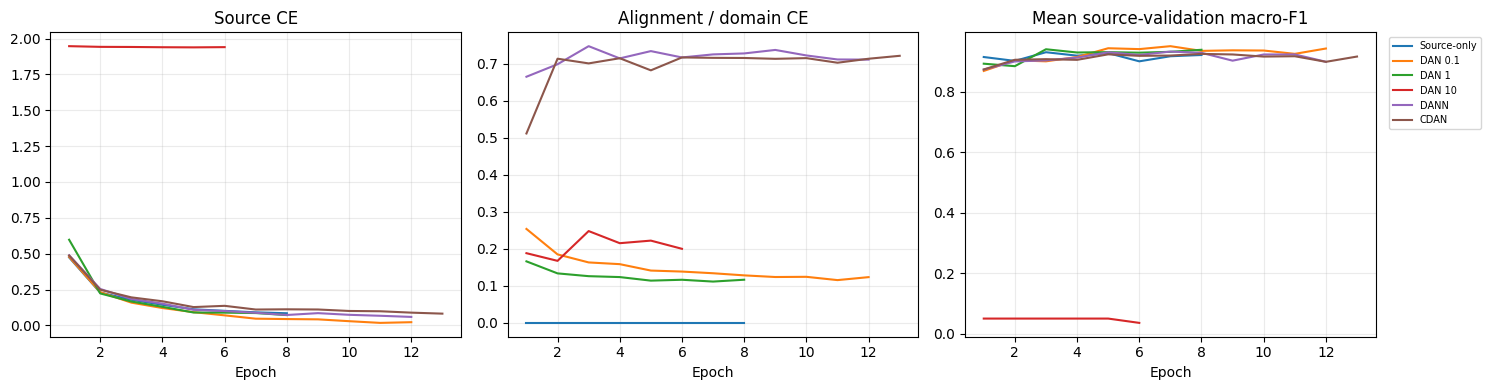

,method,best_epoch,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1,mean_source_accuracy,mean_source_macro_f1
0,Source-only,3,0.9521,0.9454,0.9000,0.8959,0.9467,0.9492,0.9329,0.9301
1,DAN 0.1,7,0.9760,0.9712,0.9146,0.9150,0.9595,0.9642,0.9501,0.9501
2,DAN 1,3,0.9581,0.9523,0.9146,0.9123,0.9488,0.9552,0.9405,0.9400
3,DAN 10,1,0.2575,0.0585,0.2195,0.0514,0.1727,0.0421,0.2166,0.0507
4,DANN,7,0.9581,0.9491,0.8976,0.8981,0.9467,0.9495,0.9341,0.9322
5,CDAN,8,0.9581,0.9516,0.8756,0.8798,0.9382,0.9425,0.9240,0.9246


In [ ]:
histories=pd.concat([pd.read_csv(OUT/(name.lower().replace(' ','_').replace('.','p').replace('-','_')+'_history.csv')) for name,_ in RUNS],ignore_index=True)
fig,ax=plt.subplots(1,3,figsize=(15,4))
for name,g in histories.groupby('method',sort=False):
    for a,key in zip(ax,['classification','alignment_or_domain','mean_source_macro_f1']):
        a.plot(g.epoch,g[key],label=name)
for a,title in zip(ax,['Source CE','Alignment / domain CE','Mean source-validation macro-F1']):a.set(xlabel='Epoch',title=title);a.grid(alpha=.25)
ax[-1].legend(fontsize=7,bbox_to_anchor=(1.02,1));fig.tight_layout()
fig.savefig(OUT/'training_curves.png',dpi=160,bbox_inches='tight');plt.show()
source_rows=[]
for name,_ in RUNS:
    safe=name.lower().replace(' ','_').replace('.','p').replace('-','_')
    ck=torch.load(OUT/f'{safe}.pt',map_location='cpu',weights_only=True)
    r={'method':name,'best_epoch':ck['epoch']}
    for d in DOMAINS:
        for metric in ('accuracy','macro_f1'):r[f'{d}_{metric}']=ck['source_validation'][d][metric]
    for metric in ('accuracy','macro_f1'):r[f'mean_source_{metric}']=np.mean([r[f'{d}_{metric}'] for d in DOMAINS])
    source_rows.append(r)
source_table=pd.DataFrame(source_rows);source_table.to_csv(OUT/'source_validation.csv',index=False)
display(source_table.round(4))

## 7. Domain Seperability Without Target Labels



In [ ]:
def load_selected(name):
    safe=name.lower().replace(' ','_').replace('.','p').replace('-','_')
    net=Net().to(DEVICE)
    net.load_state_dict(torch.load(OUT/f'{safe}.pt',map_location=DEVICE,weights_only=True)['model'])
    net.eval();return net
@torch.inference_mode()
def collect(net,dataset,labeled):
    feats=[];pred=[];truth=[]
    for batch in loader(dataset,64):
        if labeled:x,y=batch;truth.extend(y.numpy())
        else:x=batch
        f,z=net(x.to(DEVICE,non_blocking=True))
        feats.append(f.cpu().numpy());pred.extend(z.argmax(1).cpu().numpy())
    return np.concatenate(feats),np.asarray(pred),np.asarray(truth) if labeled else None
source_diag_paths=[path for d in DOMAINS for path in splits[d]['val']]
source_diag=Images(source_diag_paths,eval_tf)
sep_rows=[]
for name,_ in RUNS:
    net=load_selected(name)
    fs,_,_=collect(net,source_diag,True)
    ft,_,_=collect(net,target_diagnostic,False)
    n=min(len(fs),len(ft));rng=np.random.default_rng(SEED)
    ix=rng.choice(len(fs),n,replace=False);iy=rng.choice(len(ft),n,replace=False)
    Xdomain=np.concatenate([fs[ix],ft[iy]])
    Ydomain=np.concatenate([np.zeros(n,dtype=int),np.ones(n,dtype=int)])
    train_ix,test_ix=train_test_split(np.arange(2*n),test_size=0.3,stratify=Ydomain,random_state=SEED)
    probe=LogisticRegression(C=1.,class_weight='balanced',max_iter=2000,random_state=SEED)
    probe.fit(Xdomain[train_ix],Ydomain[train_ix])
    acc=accuracy_score(Ydomain[test_ix],probe.predict(Xdomain[test_ix]))
    sep_rows.append({'method':name,'source_n':n,'target_n':n,'heldout_domain_accuracy':acc})
    del net
separability=pd.DataFrame(sep_rows);separability.to_csv(OUT/'domain_separability.csv',index=False)
display(separability.round(4))

,method,source_n,target_n,heldout_domain_accuracy
0,Source-only,1213,1213,0.9986
1,DAN 0.1,1213,1213,0.9368
2,DAN 1,1213,1213,0.8874
3,DAN 10,1213,1213,0.6113
4,DANN,1213,1213,0.9973
5,CDAN,1213,1213,0.9986


## Task 3 Settings Configuration



In [ ]:
source_candidates=source_table[source_table.method.isin(['DAN 0.1','DAN 1','DAN 10'])]
source_choice=source_candidates.sort_values(['mean_source_macro_f1','method'],ascending=[False,True]).iloc[0]
choice={'criterion':'maximum mean macro-F1 across three source validations; lexicographic tie break',
        'selected_DAN_strength':source_choice['method'],
        'source_mean_macro_f1':float(source_choice['mean_source_macro_f1'])}
choice_file=OUT/'dan_strength_selected_without_target_labels.json'
if choice_file.exists():
    assert json.loads(choice_file.read_text())==choice,'Source-only decision changed after being saved.'
else:choice_file.write_text(json.dumps(choice,indent=2))
print('Source-validation choice (for analysis, main DAN remains λ=1):',choice)

task3_settings={'seed':SEED,'sources':DOMAINS,'unseen_target':TARGET,
    'shared_source_splits':str(split_file),'erm_checkpoint':str(OUT/'source_only_erm.pt'),
    'model':'ResNet18_Weights.IMAGENET1K_V1, same seven-class linear head',
    'preprocessing':'same 256 resize, 224 random train crop + flip, 224 center eval crop',
    'batch_per_source':8,'optimizer':'AdamW','lr':1e-4,'weight_decay':1e-4,
    'epochs_max':30,'early_stop_patience':5,'checkpoint_selection':'mean source-validation macro-F1',
    'bn':'ImageNet running stats frozen; affine trainable',
    'dan_dg_main_lambda':1,'dan_dg_study_lambdas':[0.1,1,10],
    'dan_dg':'mean of three source-pair MMDs; same kernel as Task 2',
    'sam_main_rho':0.05,'sam_type':'non-adaptive, two passes, AdamW',
    'source_domain_probe':'balanced 70/30 multinomial logistic regression C=1 seed 6304',
    'sharpness_proxy':'fixed 32 per source, rho=0.05, eval mode',
    'hypothesis':'Increasing source alignment may lower source domain separability but over-alignment can damage class recognition.'}
lock_file=OUT/'task3_settings_locked_before_target_labels.json'
if lock_file.exists():
    assert json.loads(lock_file.read_text())==task3_settings,'Task 3 settings have changed after locking.'
else:lock_file.write_text(json.dumps(task3_settings,indent=2))
print('Task 3 settings locked before Task 2 target-label evaluation:',lock_file)

Source-validation choice (for analysis, main DAN remains λ=1): {'criterion': 'maximum mean macro-F1 across three source validations; lexicographic tie break', 'selected_DAN_strength': 'DAN 0.1', 'source_mean_macro_f1': 0.9501402438818598}
Task 3 settings locked before Task 2 target-label evaluation: /content/drive/MyDrive/ATML_PA1/Task2_PACS_stabilized/results/task3_settings_locked_before_target_labels.json


## 8. Final Target Domain Evalaution



In [ ]:
assert lock_file.is_file(),'Lock Task 3 settings above first.'
assert all((OUT/(name.lower().replace(' ','_').replace('.','p').replace('-','_')+'_done.json')).is_file() for name,_ in RUNS)
target_eval=Images(target_rel,eval_tf,labeled=True)
rows=[];class_rows=[];confusion_rows=[];prediction_rows=[]
for name,_ in RUNS:
    net=load_selected(name)
    yt=[];yp=[]
    for x,y in loader(target_eval,64):
        with torch.inference_mode(): _,logits=net(x.to(DEVICE,non_blocking=True))
        yt.extend(y.numpy());yp.extend(logits.argmax(1).cpu().numpy())
    yt=np.asarray(yt);yp=np.asarray(yp)
    assert len(yt)==len(target_rel) and set(np.unique(yt))==set(range(7))
    rows.append({'method':name,'target_accuracy':accuracy_score(yt,yp),
                 'target_macro_f1':f1_score(yt,yp,labels=range(7),average='macro',zero_division=0)})
    for i,cl in enumerate(CLASSES):
        sel=yt==i
        class_rows.append({'method':name,'class':cl,'n':int(sel.sum()),'accuracy':float((yp[sel]==i).mean())})
    cm=confusion_matrix(yt,yp,labels=range(7))
    for i,actual in enumerate(CLASSES):
        for j,predicted in enumerate(CLASSES):
            confusion_rows.append({'method':name,'actual':actual,'predicted':predicted,'n':int(cm[i,j])})
    prediction_rows.extend({'method':name,'target_file':rel,'true':CLASSES[int(y)],'predicted':CLASSES[int(p)]}
                           for rel,y,p in zip(target_rel,yt,yp))
    del net
results=source_table.merge(pd.DataFrame(rows),on='method').merge(separability[['method','heldout_domain_accuracy']],on='method')
baseline=float(results.loc[results.method=='Source-only','target_accuracy'].iloc[0])
results['target_accuracy_change_pp']=100*(results.target_accuracy-baseline)
results.to_csv(OUT/'task2_summary.csv',index=False)
per_class=pd.DataFrame(class_rows);base=per_class[per_class.method=='Source-only'].set_index('class')['accuracy']
per_class['change_from_source_only_pp']=per_class.apply(lambda r:100*(r.accuracy-base[r['class']]),axis=1)
per_class.to_csv(OUT/'target_per_class.csv',index=False)
confusions=pd.DataFrame(confusion_rows);confusions.to_csv(OUT/'target_confusions.csv',index=False)
pd.DataFrame(prediction_rows).to_csv(OUT/'target_predictions.csv',index=False)
display(results.round(4))
display(per_class.pivot(index='class',columns='method',values='change_from_source_only_pp').round(1))
print('Largest per-class changes for each adapted method:')
for name,_ in RUNS[1:]:
    g=per_class[per_class.method==name].sort_values('change_from_source_only_pp')
    print(name,'decreases:',list(zip(g['class'].head(2),g.change_from_source_only_pp.head(2).round(1))),
          'increases:',list(zip(g['class'].tail(2),g.change_from_source_only_pp.tail(2).round(1))))

,method,best_epoch,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1,mean_source_accuracy,mean_source_macro_f1,target_accuracy,target_macro_f1,heldout_domain_accuracy,target_accuracy_change_pp
0,Source-only,3,0.9521,0.9454,0.9000,0.8959,0.9467,0.9492,0.9329,0.9301,0.6073,0.5716,0.9986,0.0000
1,DAN 0.1,7,0.9760,0.9712,0.9146,0.9150,0.9595,0.9642,0.9501,0.9501,0.7292,0.6773,0.9368,12.1914
2,DAN 1,3,0.9581,0.9523,0.9146,0.9123,0.9488,0.9552,0.9405,0.9400,0.6485,0.5771,0.8874,4.1232
3,DAN 10,1,0.2575,0.0585,0.2195,0.0514,0.1727,0.0421,0.2166,0.0507,0.0407,0.0112,0.6113,-56.6556
4,DANN,7,0.9581,0.9491,0.8976,0.8981,0.9467,0.9495,0.9341,0.9322,0.5274,0.5236,0.9973,-7.9919
5,CDAN,8,0.9581,0.9516,0.8756,0.8798,0.9382,0.9425,0.9240,0.9246,0.1535,0.1643,0.9986,-45.3805


method,CDAN,DAN 0.1,DAN 1,DAN 10,DANN,Source-only
class,,,,,,
dog,-11.0,29.8,25.6,-11.3,60.0,0.0
elephant,-98.1,-20.0,-33.1,-98.1,-17.3,0.0
giraffe,-56.6,13.0,12.1,-63.3,-43.4,0.0
guitar,8.1,29.9,18.4,-66.0,8.6,0.0
horse,-72.8,-2.9,-1.3,-74.0,-47.7,0.0
house,28.7,28.7,28.7,-71.2,-20.0,0.0
person,-15.0,73.8,-3.8,78.8,19.4,0.0


Largest per-class changes for each adapted method:
DAN 0.1 decreases: [('elephant', -20.0), ('horse', -2.9)] increases: [('guitar', 29.9), ('person', 73.8)]
DAN 1 decreases: [('elephant', -33.1), ('person', -3.8)] increases: [('dog', 25.6), ('house', 28.7)]
DAN 10 decreases: [('elephant', -98.1), ('horse', -74.0)] increases: [('dog', -11.3), ('person', 78.8)]
DANN decreases: [('horse', -47.7), ('giraffe', -43.4)] increases: [('person', 19.4), ('dog', 60.0)]
CDAN decreases: [('elephant', -98.1), ('horse', -72.8)] increases: [('guitar', 8.1), ('house', 28.7)]


## 9. Controlled study and failure cases


,method,mean_source_accuracy,mean_source_macro_f1,heldout_domain_accuracy,target_accuracy,target_macro_f1,target_accuracy_change_pp
1,DAN 0.1,0.9501,0.9501,0.9368,0.7292,0.6773,12.1914
2,DAN 1,0.9405,0.9400,0.8874,0.6485,0.5771,4.1232
3,DAN 10,0.2166,0.0507,0.6113,0.0407,0.0112,-56.6556



 DAN 0.1
elephant -20.0 pp; dominant confusions: [('person', 93), ('dog', 34)]
horse -2.9 pp; dominant confusions: [('house', 103), ('person', 53)]
guitar +29.9 pp; dominant confusions: [('person', 15), ('giraffe', 5)]
person +73.8 pp; dominant confusions: [('house', 8), ('dog', 0)]

 DAN 1
elephant -33.1 pp; dominant confusions: [('person', 131), ('house', 86)]
person -3.8 pp; dominant confusions: [('house', 132), ('dog', 0)]
dog +25.6 pp; dominant confusions: [('person', 209), ('horse', 111)]
house +28.7 pp; dominant confusions: [('dog', 0), ('elephant', 0)]

 DAN 10
elephant -98.1 pp; dominant confusions: [('person', 740), ('dog', 0)]
horse -74.0 pp; dominant confusions: [('person', 816), ('dog', 0)]
dog -11.3 pp; dominant confusions: [('person', 772), ('elephant', 0)]
person +78.8 pp; dominant confusions: [('dog', 0), ('elephant', 0)]

 DANN
horse -47.7 pp; dominant confusions: [('dog', 362), ('elephant', 222)]
giraffe -43.4 pp; dominant confusions: [('dog', 425), ('elephant', 74)

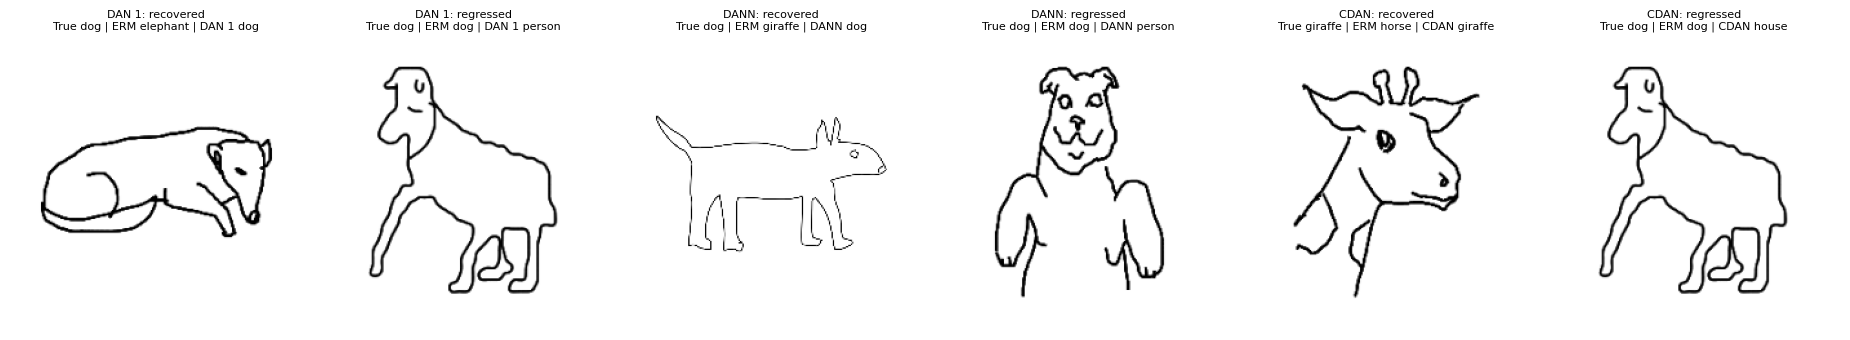

Saved all Task 2 tables, curves, checkpoints, splits and selected examples: /content/drive/MyDrive/ATML_PA1/Task2_PACS_stabilized/results


In [ ]:
study=results[results.method.isin(['DAN 0.1','DAN 1','DAN 10'])][[
 'method','mean_source_accuracy','mean_source_macro_f1','heldout_domain_accuracy',
 'target_accuracy','target_macro_f1','target_accuracy_change_pp']]
study.to_csv(OUT/'dan_strength_study.csv',index=False)
display(study.round(4))
for name in [r[0] for r in RUNS[1:]]:
    changed=per_class[per_class.method==name].sort_values('change_from_source_only_pp')
    selected=pd.concat([changed.head(2),changed.tail(2)])
    print('\n',name)
    for _,row in selected.iterrows():
        errors=confusions[(confusions.method==name)&(confusions.actual==row['class'])&
                          (confusions.actual!=confusions.predicted)].sort_values('n',ascending=False).head(2)
        print(row['class'],f"{row['change_from_source_only_pp']:+.1f} pp;",
              'dominant confusions:',[(r.predicted,int(r.n)) for r in errors.itertuples()])

pr=pd.DataFrame(prediction_rows);reference=pr[pr.method=='Source-only'].set_index('target_file')
examples=[]
for name in ('DAN 1','DANN','CDAN'):
    current=pr[pr.method==name].set_index('target_file')
    for category,mask in [('recovered',(reference.true!=reference.predicted)&(current.true==current.predicted)),
                          ('regressed',(reference.true==reference.predicted)&(current.true!=current.predicted))]:
        paths=sorted(reference.index[mask])
        if paths:examples.append((name,category,paths[0],current.loc[paths[0],'true'],
                                  reference.loc[paths[0],'predicted'],current.loc[paths[0],'predicted']))
if examples:
    fig,axes=plt.subplots(1,len(examples),figsize=(3.1*len(examples),3.4),squeeze=False)
    for ax,(name,category,path,actual,old,new) in zip(axes[0],examples):
        with Image.open(ROOT/path) as im:ax.imshow(im.convert('RGB'))
        ax.set_title(f'{name}: {category}\nTrue {actual} | ERM {old} | {name} {new}',fontsize=8);ax.axis('off')
    fig.tight_layout();fig.savefig(OUT/'target_failure_examples.png',dpi=170,bbox_inches='tight');plt.show()
pd.DataFrame(examples,columns=['method','category','target_file','true','source_only_prediction','method_prediction']).to_csv(OUT/'target_failure_examples.csv',index=False)
print('Saved all Task 2 tables, curves, checkpoints, splits and selected examples:',OUT)